In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import os
os.listdir('/content/drive/MyDrive')


['Shivani',
 '17322781341358884450817355600131.jpg',
 'Classroom',
 '1734099866725143058609226602385.jpg',
 'shivani.jpg',
 'shivanichikati _resume.pdf',
 'shivani chikati resume offical (1).pdf',
 'shivani_chikati_Data_Science.pdf',
 'shivani chikati resume offical.gdoc',
 'shivani chikati resume offical.pdf',
 'daddy files (1).pdf',
 'daddy files.pdf',
 'shivani_chikati_Data_anlytics_resume_offical (2).pdf',
 'shivani_chikati_Data_anlytics_resume_offical (1).pdf',
 'shivani_chikati_Data_anlytics_resume_offical.pdf',
 'shivani_chikati_Data_Science_resume_offical.pdf',
 'chikati_shivani_resume.pdf',
 'shivani_chikati_Data_anlytics_resume_offical.gdoc',
 'shivani_AdharCard (1).pdf',
 'shivani_AdharCard.pdf',
 'shivani_chikati_AiMl_resume.pdf',
 'shivani_chikati_AI_ML.resume.pdf',
 'shivani_chikati_python_resume .pdf',
 'WhatsApp Image 2025-09-09 at 18.22.37_8dd79b0c.jpg',
 'Colab Notebooks',
 'control structure list.gdoc',
 'recursion tracing questions (1).gdoc',
 'recursion tracing que

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
#image data generator is the package to lable the images & it will automatically lable all the images

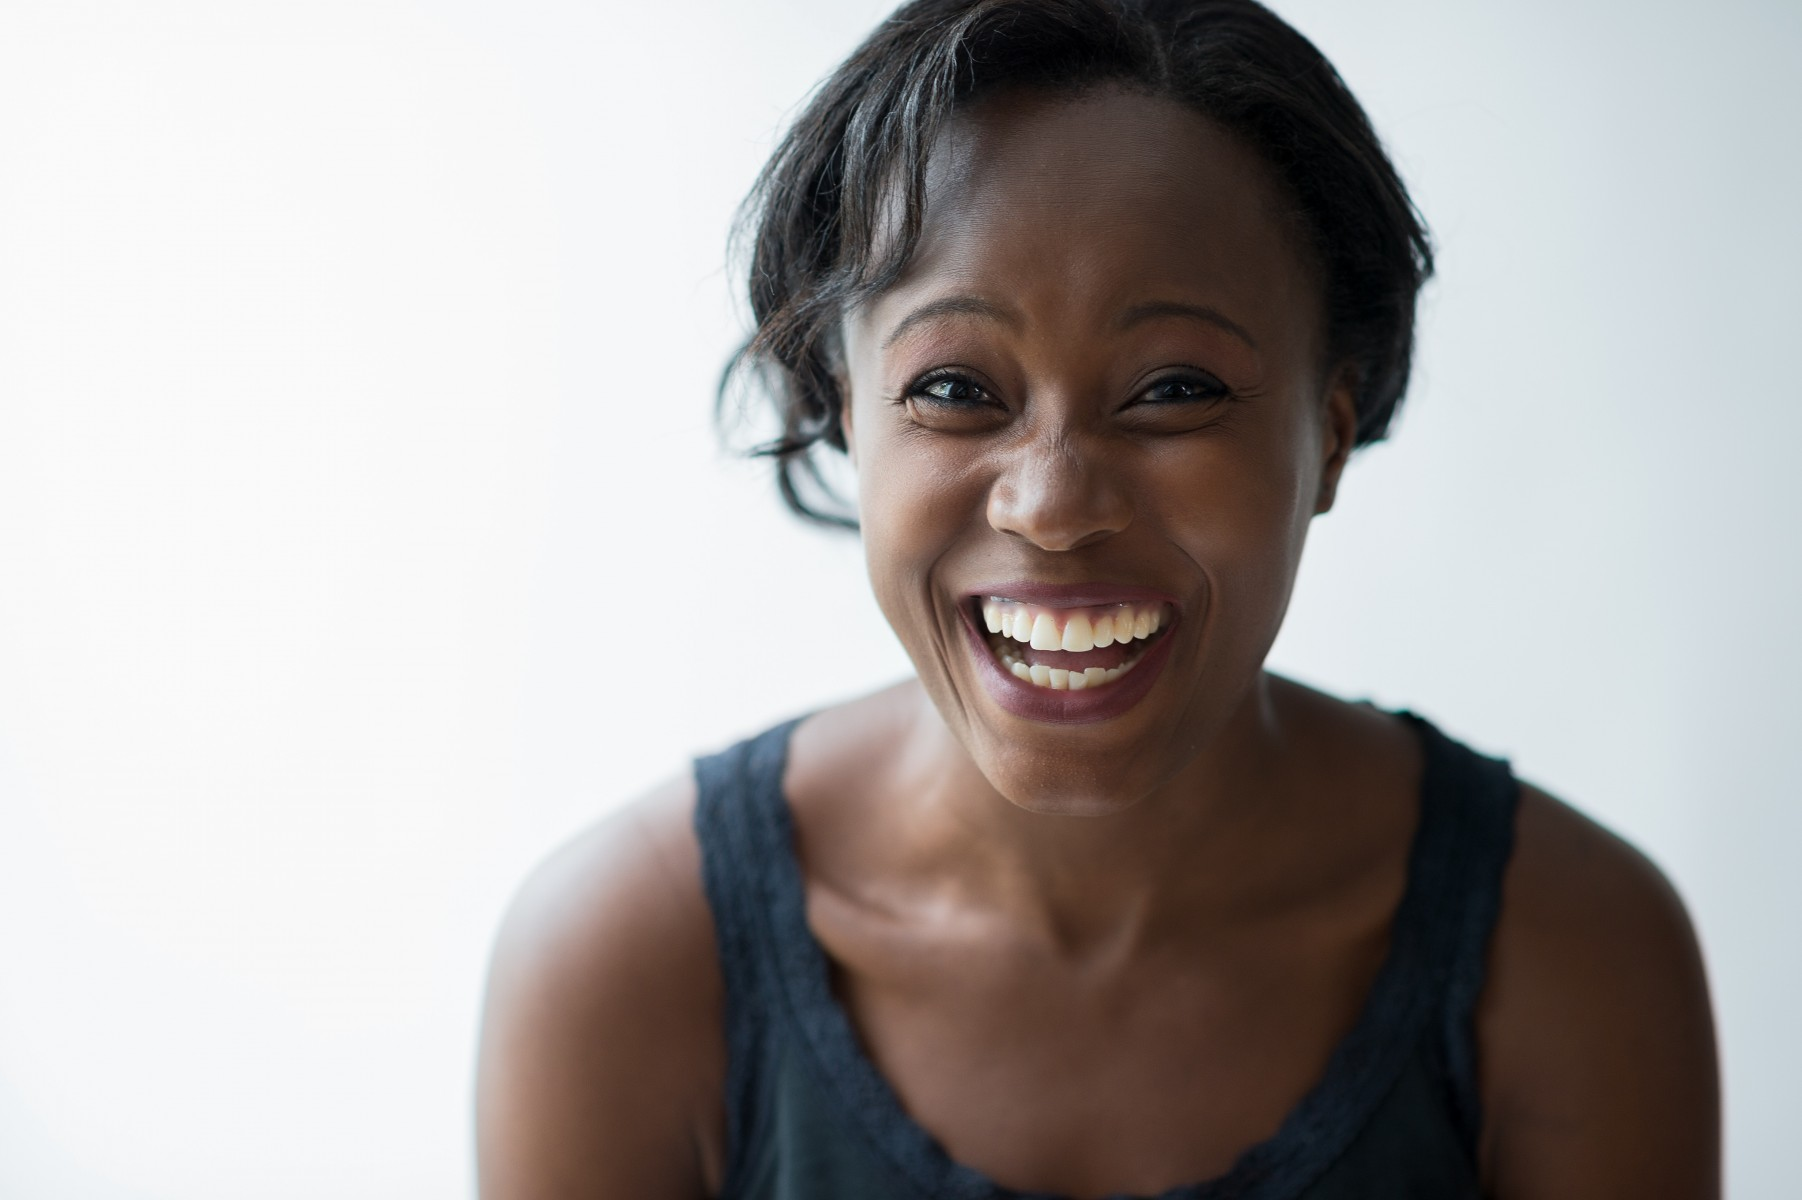

In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img('/content/drive/MyDrive/cnn_project/training/happy/happyface2.jpg')
img

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/cnn_project/training/happy'))


['happyface1.webp', 'happyface2.jpg', 'happyface4.avif', 'happyface5.webp', 'happy6.jpg', 'happyface7.webp', 'happyface8.jpg', 'happyface9.jpg', 'happyface10.webp', 'happyface11.jpg', 'happyface12.jpg', 'happyface13.jpg', 'happyface14.webp', 'happyface15.jpg']


In [ ]:

i1=cv2.imread('/content/drive/MyDrive/cnn_project/training/happy/happyface2.jpg')
i1

array([[[248, 248, 248],
        [248, 248, 248],
        [248, 248, 248],
        ...,
        [204, 201, 187],
        [204, 201, 187],
        [204, 201, 187]],

       [[248, 248, 248],
        [248, 248, 248],
        [248, 248, 248],
        ...,
        [204, 201, 187],
        [203, 200, 186],
        [203, 200, 186]],

       [[248, 248, 248],
        [248, 248, 248],
        [248, 248, 248],
        ...,
        [204, 201, 187],
        [204, 201, 187],
        [204, 201, 187]],

       ...,

       [[241, 238, 233],
        [240, 237, 232],
        [240, 237, 232],
        ...,
        [210, 204, 193],
        [209, 203, 192],
        [209, 203, 192]],

       [[241, 238, 233],
        [240, 237, 232],
        [240, 237, 232],
        ...,
        [209, 203, 192],
        [209, 203, 192],
        [209, 203, 192]],

       [[241, 238, 233],
        [241, 238, 233],
        [240, 237, 232],
        ...,
        [209, 203, 192],
        [210, 204, 193],
        [210, 204, 193]]

In [ ]:
i1.shape

(1200, 1802, 3)

In [ ]:
train=ImageDataGenerator(rescale=1/200)
validation=ImageDataGenerator(rescale=1/200)

In [ ]:
train_dataset=train.flow_from_directory('/content/drive/MyDrive/cnn_project/training',
target_size=(200,200),
batch_size=32,
class_mode='binary')
validation_dataset=validation.flow_from_directory('/content/drive/MyDrive/cnn_project/validation',
target_size=(200,200),
batch_size=32,
class_mode='binary')


Found 15 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [ ]:
train_dataset.class_indices

{'happy': 0, 'sad': 1}

In [ ]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
# now we are applying maxpooling

model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filtr we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

In [ ]:
model.compile(loss='binary_crossentropy',
            optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
            metrics=['accuracy'])


In [ ]:
model_fit = model.fit(train_dataset,epochs = 30)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0727
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0243
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0145
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0118
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0100
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0086
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0075
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0066
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0059
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0052
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0047
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0042
Epoch 13/30
1/1 ━━━━━━━━━

In [ ]:
dir_path='/content/drive/MyDrive/cnn_project/testing'
for i in os.listdir(dir_path):
  print(i)

sadpicture1.jpg
happypicture1.avif
happypicture2.jpg
happypicture3.jpg
happypicture4.jpg
happypicture5.jpg
sadpicture2.jpg
sadpicture3.jpg
sadpicture4.jpg
sadpicture5.webp


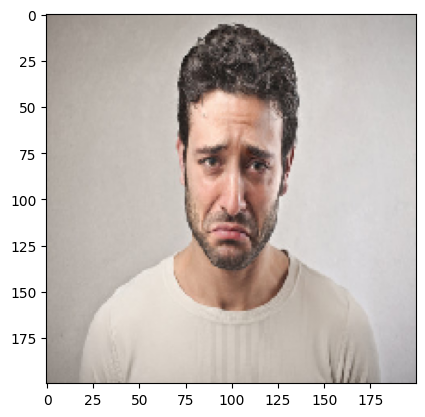

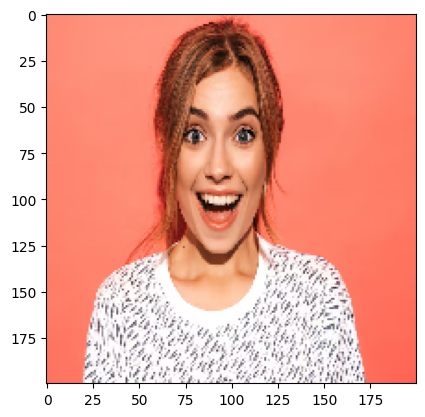

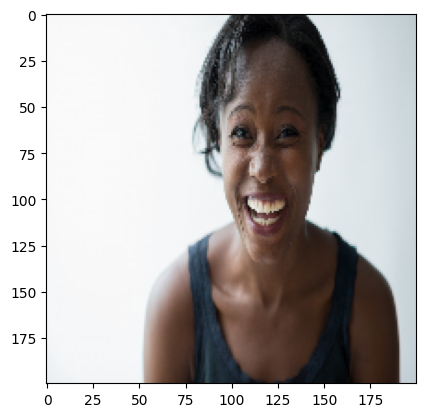

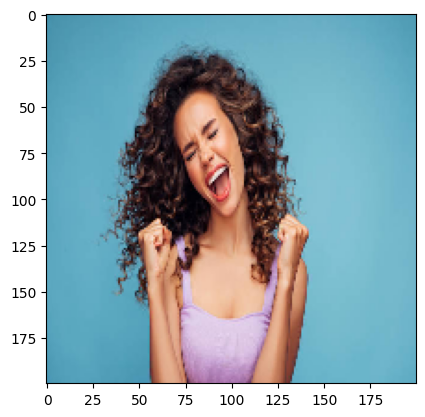

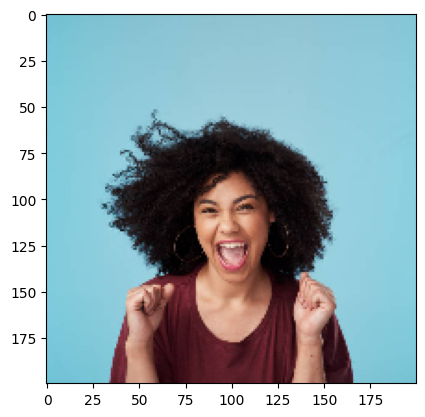

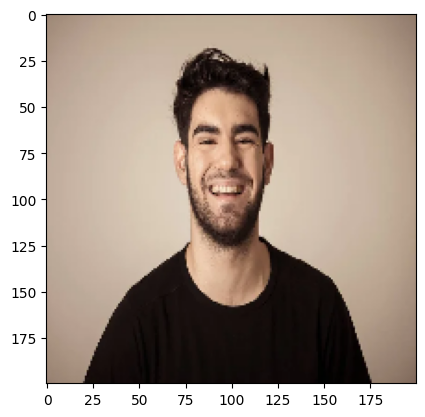

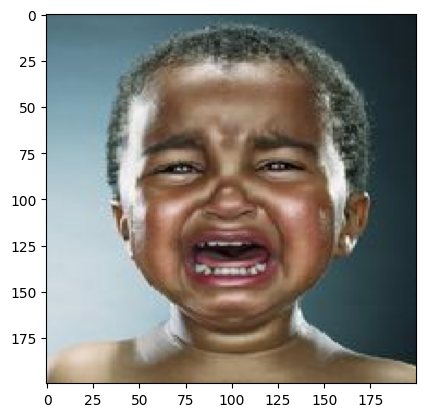

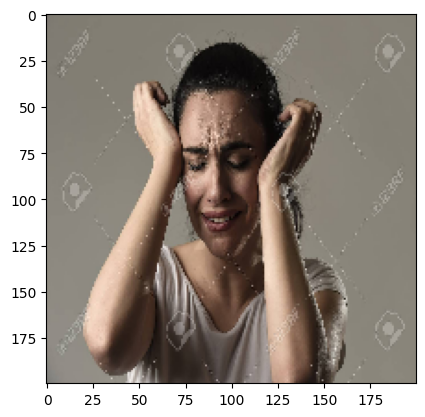

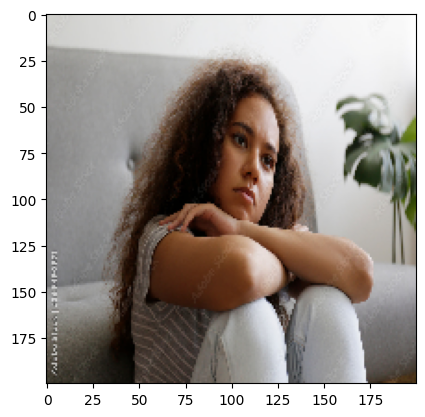

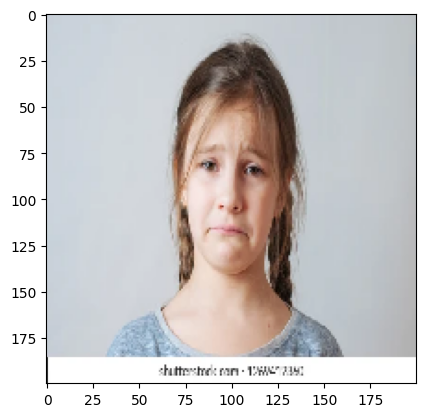

In [ ]:
dir_path = '/content/drive/MyDrive/cnn_project/testing'

for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

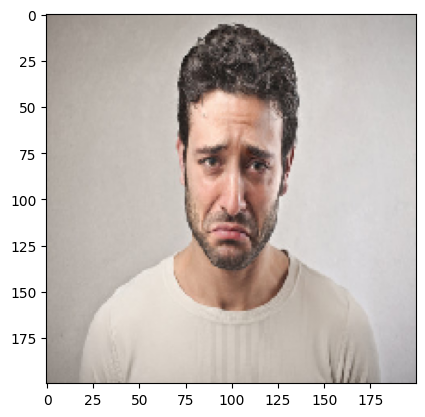

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
i am not happy


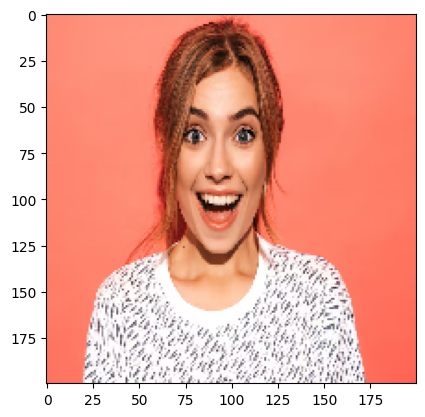

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
i am happy


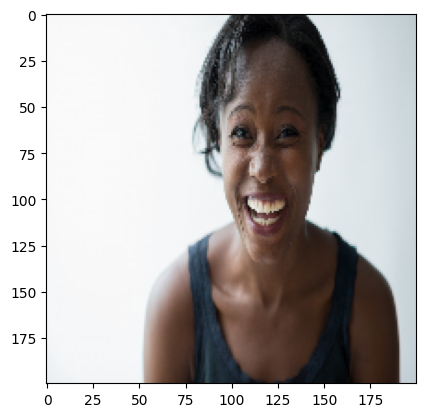

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
i am happy


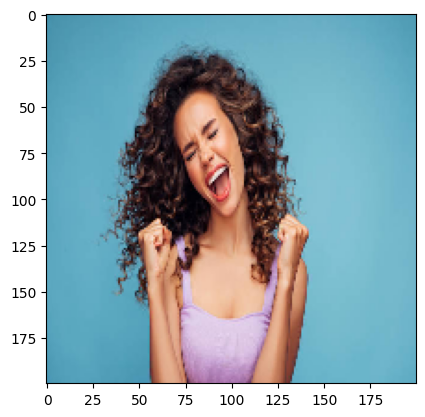

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
i am not happy


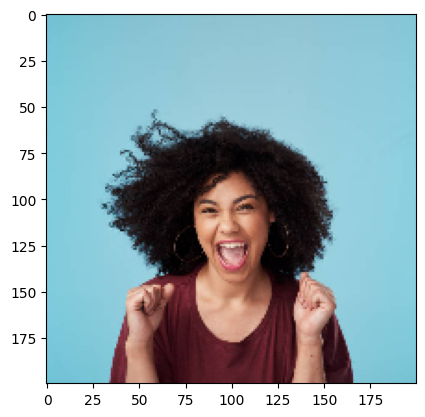

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
i am not happy


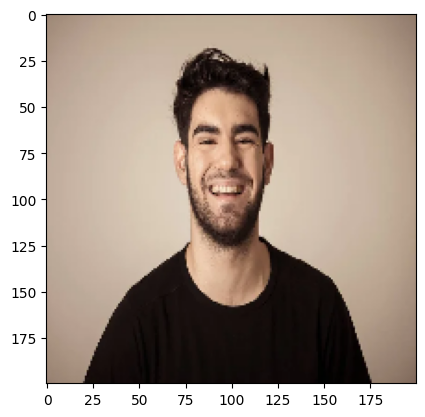

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
i am not happy


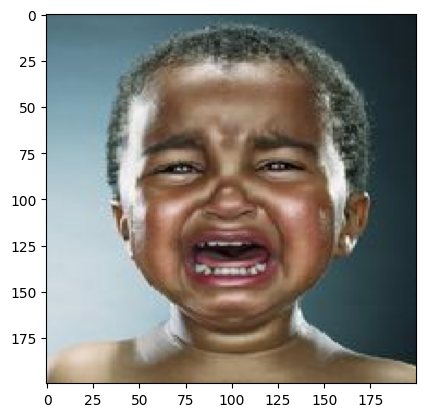

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
i am happy


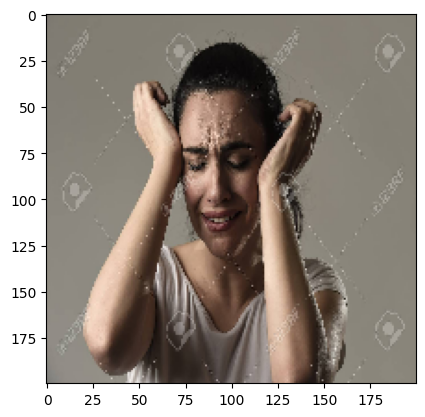

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
i am happy


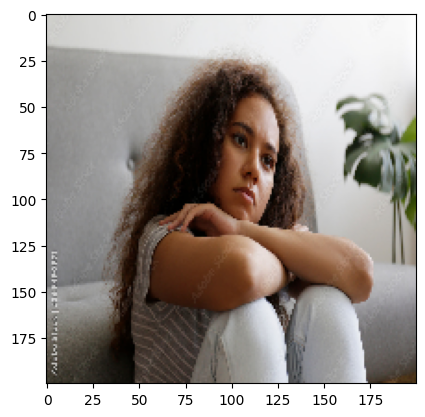

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
i am not happy


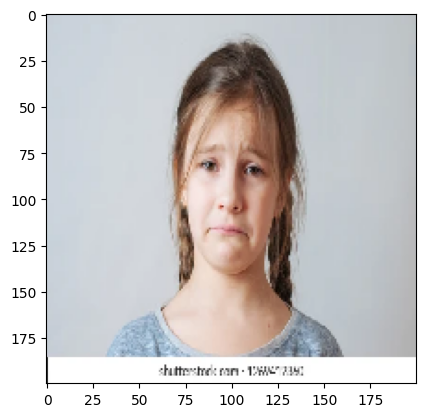

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
i am not happy


In [ ]:
dir_path = '/content/drive/MyDrive/cnn_project/testing'

for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])

    val = model.predict(images)
    if val <0.5:
        print( 'i am happy')
    else:
        print('i am not happy')

In [ ]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
    # Resize the image to (200, 200) as expected by the model
    img = image.resize((200, 200))
    # Convert the image to a numpy array
    x = np.array(img)
    # Expand dimensions to create a batch of 1 image
    x = np.expand_dims(x, axis=0)
    # Normalize the image (if the model was trained with normalized inputs)
    # The model was trained with rescale=1/200, so we should apply the same scaling here.
    x = x / 200.0

    # Make prediction
    val = model.predict(x)[0][0]

    # Interpret the prediction
    if val < 0.5:
        return 'Happy'
    else:
        return 'Not Happy'

In [ ]:
iface = gr.Interface(fn=predict_mood,
                     inputs=gr.Image(type="pil", label="Upload an image"),
                     outputs=gr.Text(label="Predicted Mood"),
                     title="Mood Classification (Happy/Not Happy)",
                     description="Upload an image to classify if the person is happy or not happy.")

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://df69f626505a1436e5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
